<a href="https://colab.research.google.com/github/yandri918/mini_project_clustering/blob/main/Mini_project_clustering_end_to_end.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
print("=" * 80)
print("BAB 27 - MINI PROJECT 5: CLUSTERING END-TO-END")
print("=" * 80)

BAB 27 - MINI PROJECT 5: CLUSTERING END-TO-END


In [3]:
# 1. LOAD DATASET
df = pd.read_csv("mini_project_clustering_pelanggan.csv")

In [4]:
print("\n[1] DATA AWAL")
print(df.head())
print("Shape awal:", df.shape)


[1] DATA AWAL
  pelanggan pendapatan_tahunan  skor_belanja  frekuensi_transaksi
0        P1                 15          39.0                    4
1        P2                 16          81.0                    8
2        P3                 17           6.0                    1
3        P4                 18          77.0                    7
4        P5                 35          40.0                    5
Shape awal: (25, 4)


In [5]:
# 2. CLEANING
print("\n[2] CLEANING")


[2] CLEANING


In [6]:
df = df.drop_duplicates()

In [7]:
for kolom in ["pendapatan_tahunan", "skor_belanja", "frekuensi_transaksi"]:
  df[kolom] = pd.to_numeric(df[kolom], errors="coerce")

In [8]:
for kolom in ["pendapatan_tahunan", "skor_belanja", "frekuensi_transaksi"]:
  df[kolom] = df[kolom].fillna(df[kolom].median())

In [9]:
print("Shape setelah cleaning:", df.shape)
print("\nMissing value setelah cleaning:")
print(df.isnull().sum())

Shape setelah cleaning: (24, 4)

Missing value setelah cleaning:
pelanggan              0
pendapatan_tahunan     0
skor_belanja           0
frekuensi_transaksi    0
dtype: int64


In [10]:
# 3. VISUALISASI AWAL


[3] VISUALISASI AWAL


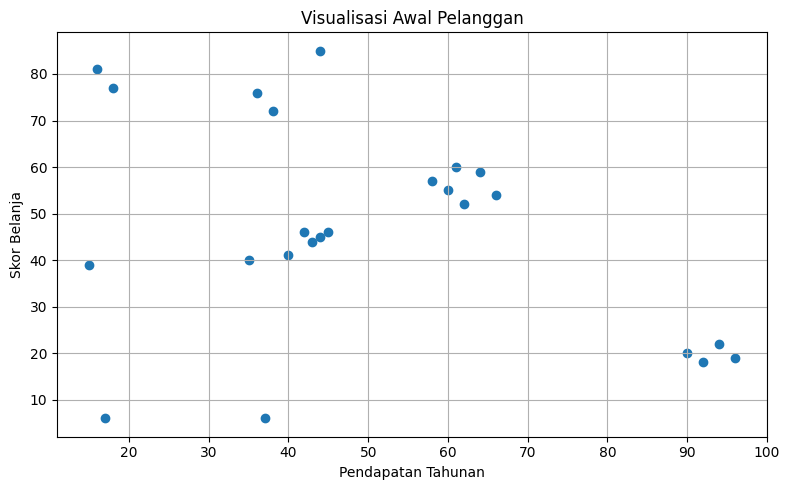

In [11]:
print("\n[3] VISUALISASI AWAL")
plt.figure(figsize=(8, 5))
plt.scatter(df["pendapatan_tahunan"], df["skor_belanja"])
plt.title("Visualisasi Awal Pelanggan")
plt.xlabel("Pendapatan Tahunan")
plt.ylabel("Skor Belanja")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 4. FITUR DAN SCALING

In [12]:
fitur = ["pendapatan_tahunan", "skor_belanja", "frekuensi_transaksi"]
X = df[fitur]

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# 5. ELBOW METHOD

In [15]:
print("\n[4] ELBOW METHOD")


[4] ELBOW METHOD


In [16]:
inertia_values = []

In [17]:
for k in range(1, 8):
  model = KMeans(n_clusters=k, random_state=42, n_init=10)
  model.fit(X_scaled)
  inertia_values.append(model.inertia_)

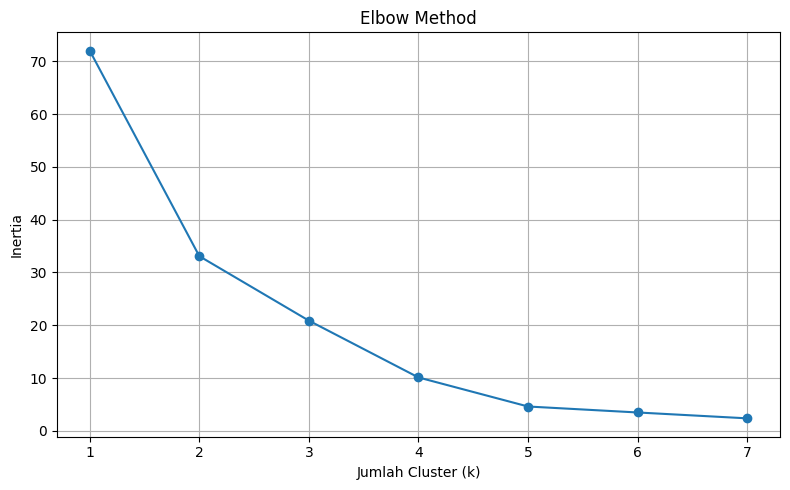

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), inertia_values, marker="o")
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 6. K-MEANS

In [19]:
print("\n[5] K-MEANS")


[5] K-MEANS


In [20]:
k_final = 4
model = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X_scaled)

In [21]:
print(df)

   pelanggan  pendapatan_tahunan  skor_belanja  frekuensi_transaksi  cluster
0         P1                15.0          39.0                    4        2
1         P2                16.0          81.0                    8        1
2         P3                17.0           6.0                    1        3
3         P4                18.0          77.0                    7        1
4         P5                35.0          40.0                    5        2
5         P6                36.0          76.0                    7        1
6         P7                37.0           6.0                    1        3
7         P8                38.0          72.0                    6        1
8         P9                60.0          55.0                    6        2
9        P10                62.0          52.0                    5        2
10       P11                64.0          59.0                    6        2
11       P12                66.0          54.0                    5        2

In [22]:
# 7. VISUALISASI CLUSTER

In [23]:
print("\n[6] VISUALISASI CLUSTER")


[6] VISUALISASI CLUSTER


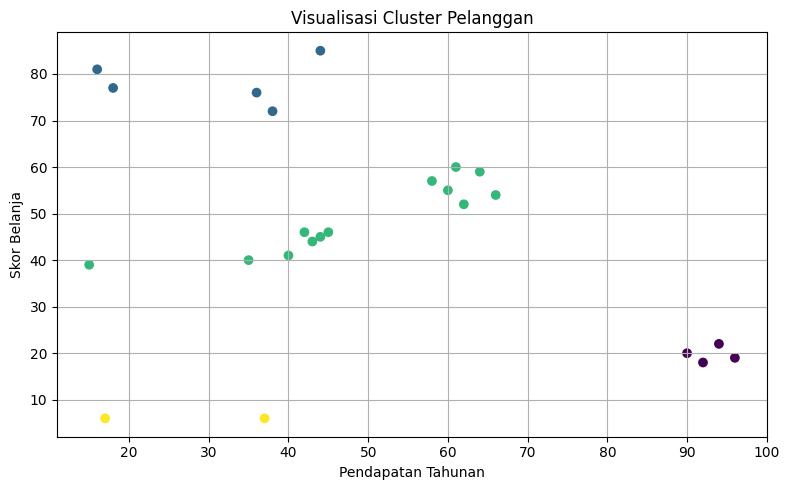

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(df["pendapatan_tahunan"], df["skor_belanja"], c=df["cluster"])
plt.title("Visualisasi Cluster Pelanggan")
plt.xlabel("Pendapatan Tahunan")
plt.ylabel("Skor Belanja")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# 8. INTERPRETASI CLUSTER

In [26]:
print("\n[7] RINGKASAN CLUSTER")
ringkasan = df.groupby("cluster")[[ "pendapatan_tahunan", "skor_belanja", "frekuensi_transaksi" ]].mean()


[7] RINGKASAN CLUSTER


In [27]:
print(ringkasan)

         pendapatan_tahunan  skor_belanja  frekuensi_transaksi
cluster                                                       
0                 93.000000     19.750000                 1.75
1                 30.400000     78.200000                 7.20
2                 48.846154     49.076923                 5.00
3                 27.000000      6.000000                 1.00


In [28]:
# 9. INSIGHT BISNIS

In [29]:
print("\n[8] INSIGHT BISNIS SEDERHANA")
print("- Pelanggan dapat dibagi ke beberapa segmen perilaku yang berbeda.")
print("- Ada segmen pelanggan berpendapatan tinggi tetapi kurang aktif belanja.")
print("- Ada segmen pelanggan yang aktif belanja dan layak diprioritaskan untuk loyalitas.")
print("- Segmentasi ini bisa dipakai untuk strategi promosi yang lebih terarah.")


[8] INSIGHT BISNIS SEDERHANA
- Pelanggan dapat dibagi ke beberapa segmen perilaku yang berbeda.
- Ada segmen pelanggan berpendapatan tinggi tetapi kurang aktif belanja.
- Ada segmen pelanggan yang aktif belanja dan layak diprioritaskan untuk loyalitas.
- Segmentasi ini bisa dipakai untuk strategi promosi yang lebih terarah.


In [30]:
# 10. SIMPAN HASIL

In [36]:
import os
os.makedirs("Outputs", exist_ok=True)

In [37]:
df.to_csv("Outputs/bab27_hasil_cluster_final.csv", index=False)

In [38]:
print("\nHasil cluster disimpan ke outputs/bab27_hasil_cluster_final.csv")


Hasil cluster disimpan ke outputs/bab27_hasil_cluster_final.csv


In [39]:
print("\nSELESAI. Anda sudah menjalankan mini project clustering end-to-end.")
print("=" * 80)


SELESAI. Anda sudah menjalankan mini project clustering end-to-end.
